In [27]:
import os
from pathlib import Path
import shutil
import tempfile

import duckdb
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import scipy.stats as stats
from dotenv import load_dotenv, find_dotenv

In [28]:
# Load environment (if present) and connect to DuckDB read-only.
# On Windows, DuckDB may fail if another process holds an exclusive lock.
dotenv_path = find_dotenv(usecwd=True)
if dotenv_path:
    load_dotenv(dotenv_path, override=False)
else:
    # Fallback: typical repo layout where notebook is in ./signals and .env is at repo root
    load_dotenv(Path('..') / '.env', override=False)
    
# Resolve repo root (works whether cwd is repo root or ./signals)
cwd = Path.cwd().resolve()
repo_root = cwd.parent if cwd.name.lower() == 'signals' else cwd

default_db_path = repo_root / 'data' / 'ohlcv_1m.duckdb'
DB_PATH = Path(os.getenv('DUCKDB_PATH', str(default_db_path))).expanduser()
DB_PATH = (repo_root / DB_PATH).resolve() if not DB_PATH.is_absolute() else DB_PATH.resolve()

def connect_duckdb_readonly(db_path: Path):
    try:
        return duckdb.connect(str(db_path), read_only=True)
    except Exception as e:
        msg = str(e).lower()
        locked = ('being used by another process' in msg) or ('used by another process' in msg)
        if locked:
            # Fallback: try copying the DB to a temp path and opening that copy read-only.
            tmp_dir = Path(tempfile.gettempdir()) / 'margincallcapital'
            tmp_dir.mkdir(parents=True, exist_ok=True)
            db_copy_path = tmp_dir / f'{db_path.stem}_copy{db_path.suffix}'
            try:
                shutil.copy2(db_path, db_copy_path)
                print(f'DB appears locked; using temp copy: {db_copy_path}')
                return duckdb.connect(str(db_copy_path), read_only=True)
            except Exception as copy_err:
                raise RuntimeError(
                    f"DuckDB DB is locked and couldn't be copied.\n\nOriginal error: {e}\nCopy error: {copy_err}\n\n"
                    "Close any DuckDB viewer/extension or other process connected to the DB, then retry."
                )
        raise

con = connect_duckdb_readonly(DB_PATH)
print(f'Connected to {DB_PATH}')

Connected to C:\Users\User\Desktop\MarginCallCapital\margincallcapital\data\ohlcv_1m.duckdb


# Connect to DB

In [29]:
# List tables
tables = con.sql("SHOW TABLES").df()
tables

# Load close data for multiple symbols at the base interval, then we'll resample to other timeframes.
base_interval = "1m"

symbols_df = con.execute(
    """
    SELECT DISTINCT symbol
    FROM ohlcv
    WHERE interval = ? AND symbol NOT LIKE '%USDT%'
    ORDER BY symbol
    """,
    [base_interval],
).df()

symbols = symbols_df["symbol"].astype(str).tolist()
print(f"Found {len(symbols)} symbols at interval={base_interval}")

# For quick iteration, start with a smaller universe (adjust as you like).
# symbols = symbols[:25]
print("Using symbols:", symbols)

def load_close_matrix(con, symbols, interval: str) -> pd.DataFrame:
    if not symbols:
        raise ValueError("No symbols provided")
    placeholders = ", ".join(["?"] * len(symbols))
    sql = f"""
    SELECT ts, symbol, close
    FROM ohlcv
    WHERE interval = ? AND symbol IN ({placeholders})
    ORDER BY ts
    """
    df_long = con.execute(sql, [interval, *symbols]).df()
    df_long["ts"] = pd.to_datetime(df_long["ts"])
    close_wide = (
        df_long.pivot(index="ts", columns="symbol", values="close")
        .sort_index()
        .astype(float)
    )
    return close_wide

close_1m = load_close_matrix(con, symbols, base_interval)
close_1m.tail()

Found 66 symbols at interval=1m
Using symbols: ['1000CHEEMS-USD', 'AAVE-USD', 'ADA-USD', 'APT-USD', 'ARB-USD', 'ASTER-USD', 'AVAX-USD', 'AVNT-USD', 'BIO-USD', 'BMT-USD', 'BNB-USD', 'BONK-USD', 'BTC-USD', 'CAKE-USD', 'CFX-USD', 'CRV-USD', 'DOGE-USD', 'DOT-USD', 'EDEN-USD', 'EIGEN-USD', 'ENA-USD', 'ETH-USD', 'FET-USD', 'FIL-USD', 'FLOKI-USD', 'FORM-USD', 'HBAR-USD', 'HEMI-USD', 'ICP-USD', 'LINEA-USD', 'LINK-USD', 'LISTA-USD', 'LTC-USD', 'MIRA-USD', 'NEAR-USD', 'ONDO-USD', 'OPEN-USD', 'PAXG-USD', 'PENDLE-USD', 'PENGU-USD', 'PEPE-USD', 'PLUME-USD', 'POL-USD', 'PUMP-USD', 'S-USD', 'SEI-USD', 'SHIB-USD', 'SOL-USD', 'SOMI-USD', 'STO-USD', 'SUI-USD', 'TAO-USD', 'TON-USD', 'TRUMP-USD', 'TRX-USD', 'TUT-USD', 'UNI-USD', 'VIRTUAL-USD', 'WIF-USD', 'WLD-USD', 'WLFI-USD', 'XLM-USD', 'XPL-USD', 'XRP-USD', 'ZEC-USD', 'ZEN-USD']


symbol,1000CHEEMS-USD,AAVE-USD,ADA-USD,APT-USD,ARB-USD,ASTER-USD,AVAX-USD,AVNT-USD,BIO-USD,BMT-USD,...,UNI-USD,VIRTUAL-USD,WIF-USD,WLD-USD,WLFI-USD,XLM-USD,XPL-USD,XRP-USD,ZEC-USD,ZEN-USD
ts,,,,,,,,,,,,,,,,,,,,,
2026-03-19 00:59:00+08:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,3.648,0.7258,0.175,0.3596,0.0987,0.1674,0.1075,1.4424,250.11,6.108
2026-03-19 01:00:00+08:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,3.650,0.7253,0.175,0.3594,0.0987,0.1674,0.1078,1.4421,247.79,6.091
2026-03-19 01:01:00+08:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,3.650,0.7226,0.174,0.3582,0.0986,0.1671,0.1076,1.4403,246.23,6.075
2026-03-19 01:02:00+08:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,3.651,0.7229,0.174,0.3586,0.0986,0.1671,0.1075,1.4409,244.79,6.066
2026-03-19 01:03:00+08:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,0.1075,1.4412,245.14,6.056


## Skeleton for coin momentum

## Momentum over time

Compute rolling-window momentum from the combined cross-sectional score and visualize:
- Market-wide average momentum (spot + rolling windows).
- Per-coin rolling momentum trajectories for leaders/laggards.

Windows are expressed in 1h bars: `24h = 24`, `3d = 72`, `7d = 168`.

In [30]:
# -------------------------------------------------------------------
# 1. CORE SIGNAL GENERATION (Fully Vectorized)
# -------------------------------------------------------------------

def calculate_matrix_signal(close_df: pd.DataFrame, fast_span: int, slow_span: int, vol_span: int) -> pd.DataFrame:
    """
    Calculates the momentum z-score for an entire price matrix simultaneously.
    """
    # Calculate EMAs across all columns at once (no loops needed)
    ma_s = close_df.ewm(span=fast_span, adjust=False).mean()
    ma_l = close_df.ewm(span=slow_span, adjust=False).mean()
    
    spread = ma_s - ma_l
    
    # Volatility normalization (parameterized so it fits the timeframe)
    spread_std = spread.ewm(span=vol_span, adjust=False).std()
    
    # Calculate Z-score (safeguard against division by zero)
    z_score = spread / spread_std.replace(0.0, np.nan)
    
    # CRITICAL: Shift by 1 bar in the native timeframe to prevent lookahead bias
    return z_score.shift(1)

def cross_sectional_rank_to_unit(z_score_df: pd.DataFrame) -> pd.DataFrame:
    """
    Row-wise percentile rank mapped to [-1, 1].
    """
    pct = z_score_df.rank(axis=1, pct=True, method='average')
    return pct * 2 - 1

# -------------------------------------------------------------------
# 2. TIMEFRAME CONFIGURATION
# -------------------------------------------------------------------
# Added 'vol' to parameterize the volatility normalization window for each timeframe.

# TIMEFRAMES = {
#     '1h':  {'rule': '1h', 'fast': 24, 'slow': 72, 'vol': 260},  # ~10 days of vol on 1h
#     '4h':  {'rule': '4h', 'fast': 18, 'slow': 54, 'vol': 180},  # ~30 days of vol on 4h
#     '1d':  {'rule': '1D', 'fast': 20, 'slow': 60, 'vol': 90},   # 90 days of vol on daily
# }

TIMEFRAMES = {
    # 1-Minute
    '1m':  {'rule': '1min',  'fast': 30, 'slow': 90, 'vol': 1440},  # Fast: 30m, Slow: 1.5h, Vol: 24h
    # 5-Minute
    '5m':  {'rule': '5min',  'fast': 24, 'slow': 72, 'vol': 576},   # Fast: 2h, Slow: 6h, Vol: 2 days
    # 15-Minute
    '15m': {'rule': '15min', 'fast': 16, 'slow': 48, 'vol': 672},   # Fast: 4h, Slow: 12h, Vol: 7 days
}

# -------------------------------------------------------------------
# 3. EXECUTION PIPELINE
# -------------------------------------------------------------------

# Assuming `close_1m` is your base DataFrame of minute closes
signals_by_tf = {}
xsec_momentum_by_tf = {}

for name, cfg in TIMEFRAMES.items():
    # 1. Resample to the target timeframe
    if cfg['rule'] == '1min':
        close_tf = close_1m 
    else:
        # label='right', closed='right' ensures the daily bar timestamp represents the end of the day
        close_tf = close_1m.resample(cfg['rule'], label='right', closed='right').last()
    
    # 2. Compute the vectorized z-score signal (this handles the shift(1) internally)
    sig_tf = calculate_matrix_signal(close_tf, cfg['fast'], cfg['slow'], cfg['vol'])
    
    # 3. Rank cross-sectionally
    xsec_tf = cross_sectional_rank_to_unit(sig_tf)
    
    # 4. Project back to the hourly grid (forward fill)
    # The signal generated at the end of Monday is now available at 00:00 Tuesday.
    xsec_tf_aligned = xsec_tf.reindex(close_1m.index, method='ffill')
    
    signals_by_tf[name] = sig_tf
    xsec_momentum_by_tf[name] = xsec_tf_aligned

# -------------------------------------------------------------------
# 4. AGGREGATION
# -------------------------------------------------------------------

# Combine timeframes into a single cross-coin momentum score.
# Using pd.concat to group by index natively handles mean calculations while ignoring NaNs.
combined_xsec = pd.concat(xsec_momentum_by_tf.values()).groupby(level=0).mean()

# Example outputs
print('Signal matrix (1m) tail:')
print(signals_by_tf['1m'].tail())

print('\nCombined cross-coin momentum tail:')
print(combined_xsec.tail())

# Latest ranking snapshot
latest = combined_xsec.dropna(how='all').iloc[-1].sort_values(ascending=False)
print('\nLatest Top 10 Momentum Coins:')
print(latest.head(10))

Signal matrix (1m) tail:
symbol                     1000CHEEMS-USD  AAVE-USD   ADA-USD   APT-USD  \
ts                                                                        
2026-03-19 00:59:00+08:00       -0.739263 -0.169737 -0.356931  0.123502   
2026-03-19 01:00:00+08:00       -0.739765 -0.169829 -0.357170  0.123556   
2026-03-19 01:01:00+08:00       -0.740267 -0.169921 -0.357410  0.123609   
2026-03-19 01:02:00+08:00       -0.740770 -0.170012 -0.357650  0.123663   
2026-03-19 01:03:00+08:00       -0.741274 -0.170104 -0.357890  0.123717   

symbol                      ARB-USD  ASTER-USD  AVAX-USD  AVNT-USD   BIO-USD  \
ts                                                                             
2026-03-19 00:59:00+08:00 -0.400655   0.519742 -0.473910 -1.463531 -0.316336   
2026-03-19 01:00:00+08:00 -0.400917   0.519718 -0.474228 -1.463800 -0.316548   
2026-03-19 01:01:00+08:00 -0.401179   0.519695 -0.474546 -1.464071 -0.316760   
2026-03-19 01:02:00+08:00 -0.401441   0.519673 -0

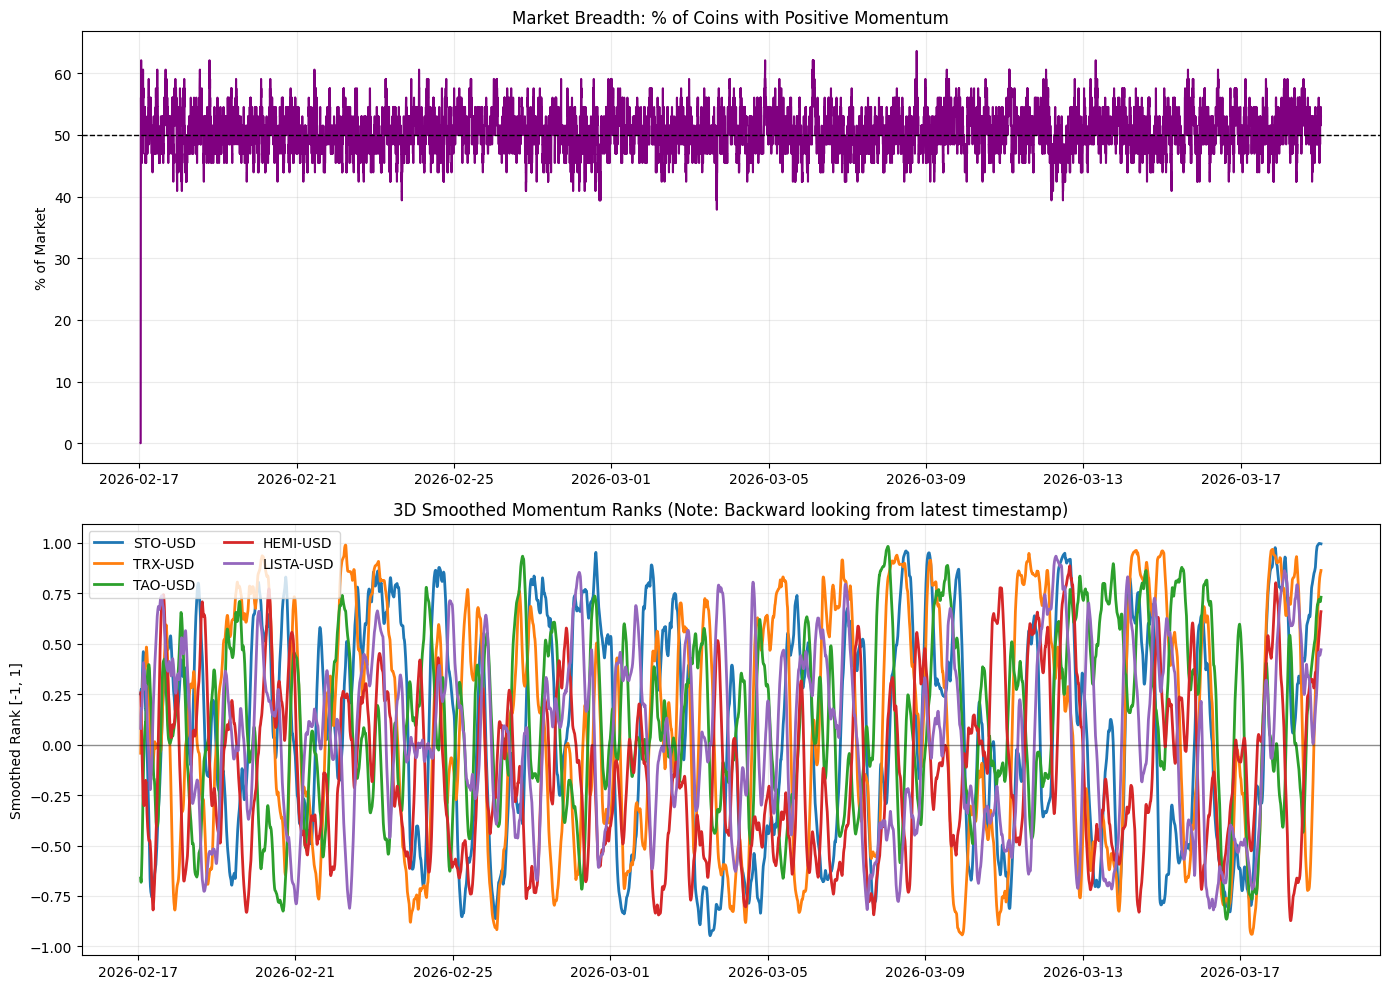

In [34]:
# -------------------------------------------------------------------
# 1. ROLLING SMOOTHING (For churn reduction)
# -------------------------------------------------------------------
if 'combined_xsec' not in globals():
    raise RuntimeError('Run the previous momentum cell first.')

# rolling_windows = {'1d': 24, '3d': 72, '7d': 168}
rolling_windows = {'1h':60, '4h':240, '12h':720}  # Adjusted for the 1m base data (60m in 1h, 240m in 4h, 1440m in 1d)
rolling_scores = {}

for label, window in rolling_windows.items():
    # min_periods = max(3, window // 4)
    # Require at least 15 minutes of data to start plotting, otherwise wait for 1/4 of window
    min_periods = max(15, window // 4)
    # Smoothing the ranks to create a "slowed down" allocation signal
    rolling_scores[label] = combined_xsec.rolling(window=window, min_periods=min_periods).mean()

# -------------------------------------------------------------------
# 2. MARKET BREADTH (Fixing the Zero-Mean Trap)
# -------------------------------------------------------------------
# Instead of averaging ranks, we calculate what % of the market is in an "uptrend"
# We'll use the 4h signal from the previous step (before it was ranked)
if 'signals_by_tf' in globals() and '4h' in signals_by_tf:
    raw_4h_zscore = signals_by_tf['4h']
    # % of coins with a positive Z-score (bullish momentum)
    market_breadth = (raw_4h_zscore > 0).mean(axis=1) * 100 
else:
    # Fallback if raw signals aren't available: % of coins above 0 in the rank 
    # (less accurate, but works as a proxy)
    market_breadth = (combined_xsec > 0).mean(axis=1) * 100

# -------------------------------------------------------------------
# 3. SNAPSHOT & VISUALIZATION
# -------------------------------------------------------------------
latest_ts = combined_xsec.dropna(how='all').index[-1]
latest_snapshot = pd.DataFrame({'spot': combined_xsec.loc[latest_ts]})
for label, df in rolling_scores.items():
    latest_snapshot[label] = df.loc[latest_ts]

# Sort by the 1h smoothed rank for a more stable top/bottom selection
rank_col = '1h' if latest_snapshot['1h'].notna().any() else 'spot'
latest_snapshot = latest_snapshot.sort_values(rank_col, ascending=False)

fig, axes = plt.subplots(2, 1, figsize=(14, 10), sharex=False)

# --- Plot 1: Market Breadth ---
axes[0].plot(market_breadth.index, market_breadth, color='purple', linewidth=1.5)
axes[0].axhline(50.0, color='black', linewidth=1, linestyle='--')
axes[0].set_title('Market Breadth: % of Coins with Positive Momentum')
axes[0].set_ylabel('% of Market')
axes[0].grid(alpha=0.25)

# --- Plot 2: Top vs Bottom Trajectories (Warning: Hindsight Bias applied!) ---
coin_plot_df = rolling_scores['4h']
top_symbols = latest_snapshot.head(5).index.tolist()

for sym in top_symbols:
    if sym in coin_plot_df.columns:
        axes[1].plot(coin_plot_df.index, coin_plot_df[sym], linewidth=2, label=f'{sym}')


axes[1].axhline(0.0, color='black', linewidth=1, alpha=0.4)
axes[1].set_title('3D Smoothed Momentum Ranks (Note: Backward looking from latest timestamp)')
axes[1].set_ylabel('Smoothed Rank [-1, 1]')
axes[1].legend(loc='upper left', ncol=2)
axes[1].grid(alpha=0.25)

plt.tight_layout()
plt.show()

C:\Users\User\AppData\Local\Temp\ipykernel_7476\2770629560.py:11: FutureWarning: The default fill_method='pad' in DataFrame.pct_change is deprecated and will be removed in a future version. Either fill in any non-leading NA values prior to calling pct_change or specify 'fill_method=None' to not fill NA values.
  fwd_returns = close_1m.pct_change(periods=horizon_bars).shift(-horizon_bars)


--- IC Summary Statistics ---
Mean IC:      -0.0256
IC Std Dev:   0.1777
IC IR (Risk): -0.1439  (> 0.5 is good, > 1.0 is exceptional)
Hit Rate:     43.43% (> 50% is required for edge)


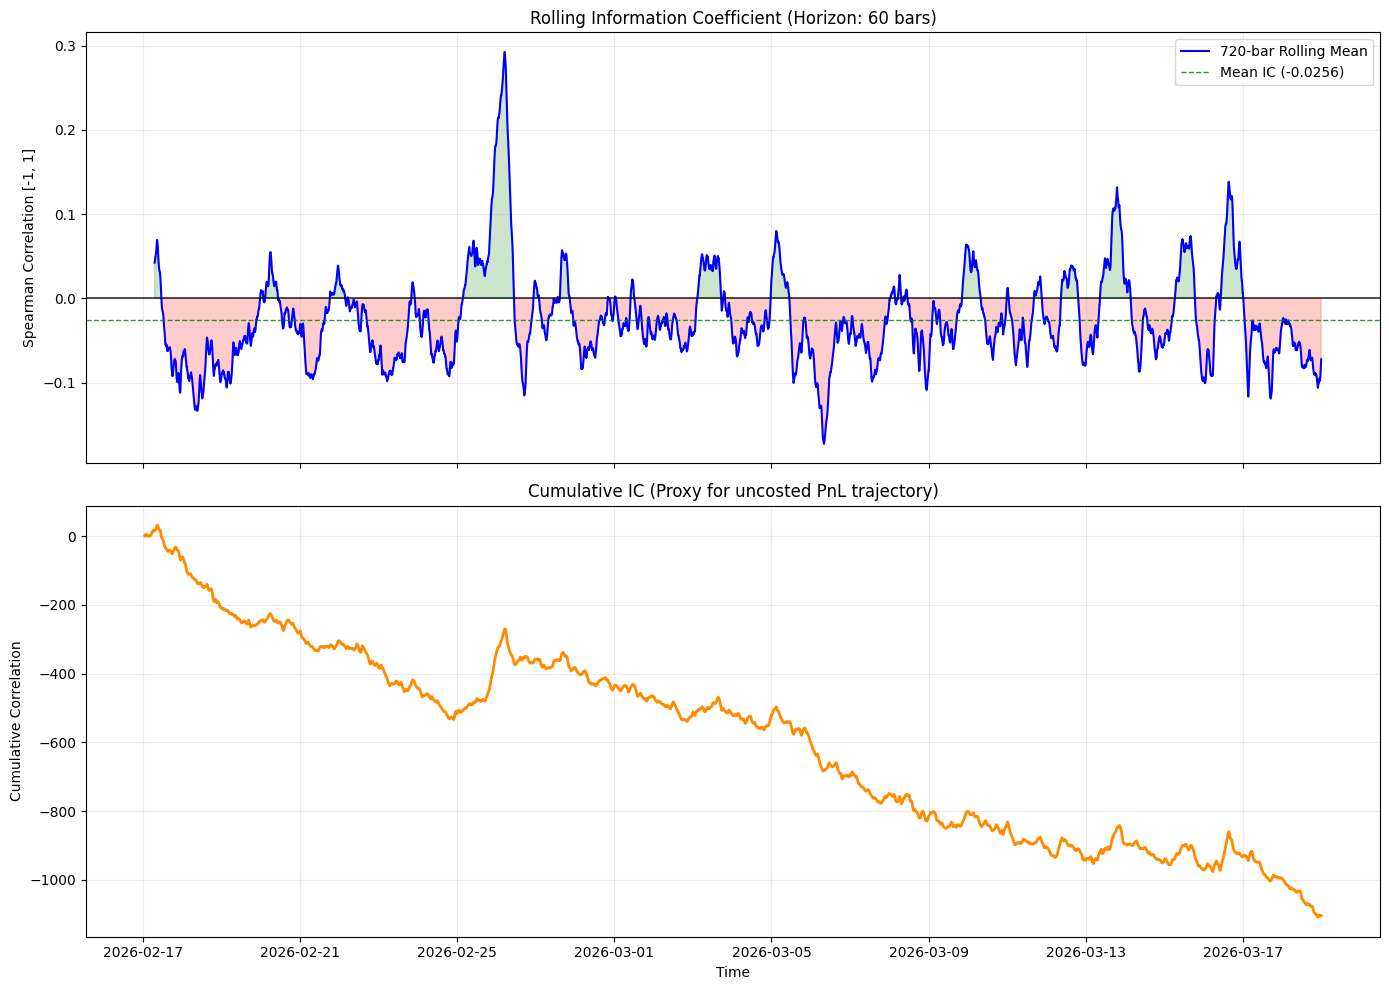

In [35]:
# -------------------------------------------------------------------
# 1. CALCULATE FORWARD RETURNS
# -------------------------------------------------------------------
# We need to define our evaluation horizon. 
# If our signal is built for a 3-day hold, evaluating 1-hour forward returns is mostly noise.
# Let's use a 24-hour (1-day) forward return for this example.
horizon_bars = 60  # 60 bars of 1-minute data = 1 hour forward return 

# pct_change gives the backward return. We shift it negatively to make it the FORWARD return.
# At time 't', this cell contains the return from 't' to 't + horizon_bars'
fwd_returns = close_1m.pct_change(periods=horizon_bars).shift(-horizon_bars)

# -------------------------------------------------------------------
# 2. CALCULATE CROSS-SECTIONAL IC (Spearman Rank Correlation)
# -------------------------------------------------------------------
# We align our signal (combined_xsec) with the forward returns.
# Because combined_xsec is already shifted by 1 in earlier steps, there is no lookahead bias.

# Pandas corrwith(axis=1) computes the correlation row-by-row (timestamp-by-timestamp)
# We use 'spearman' to evaluate the rank-ordering power of the signal.
ic_series = combined_xsec.corrwith(fwd_returns, axis=1, method='spearman')

# Drop NaNs that occur at the end of the dataset due to the forward shift
ic_series = ic_series.dropna()

# -------------------------------------------------------------------
# 3. METRICS & SMOOTHING
# -------------------------------------------------------------------
# Raw IC is incredibly noisy. We smooth it with a rolling mean to see structural trends.
# rolling_window = 24 * 7  # 7-day rolling window
rolling_window = 60 * 4  # 12-hour rolling window (adjust based on your horizon and data frequency)
rolling_ic = ic_series.rolling(window=rolling_window, min_periods=rolling_window//2).mean()

# Cumulative IC is a great proxy for un-levered, un-costed strategy performance.
cumulative_ic = ic_series.cumsum()

# Key Summary Statistics
mean_ic = ic_series.mean()
std_ic = ic_series.std()
ic_ir = mean_ic / std_ic if std_ic != 0 else 0  # Information Ratio of the IC
hit_rate = (ic_series > 0).mean() * 100         # % of periods with positive prediction

print("--- IC Summary Statistics ---")
print(f"Mean IC:      {mean_ic:.4f}")
print(f"IC Std Dev:   {std_ic:.4f}")
print(f"IC IR (Risk): {ic_ir:.4f}  (> 0.5 is good, > 1.0 is exceptional)")
print(f"Hit Rate:     {hit_rate:.2f}% (> 50% is required for edge)")

# -------------------------------------------------------------------
# 4. VISUALIZATION
# -------------------------------------------------------------------
fig, axes = plt.subplots(2, 1, figsize=(14, 10), sharex=True)

# --- Plot 1: Rolling IC ---
axes[0].plot(rolling_ic.index, rolling_ic, color='blue', linewidth=1.5, label=f'{rolling_window}-bar Rolling Mean')
axes[0].axhline(0.0, color='black', linewidth=1.2, alpha=0.8)
axes[0].axhline(mean_ic, color='green', linestyle='--', linewidth=1, alpha=0.8, label=f'Mean IC ({mean_ic:.4f})')

# Fill between to highlight positive vs negative regimes
axes[0].fill_between(rolling_ic.index, rolling_ic, 0, where=(rolling_ic >= 0), color='green', alpha=0.2)
axes[0].fill_between(rolling_ic.index, rolling_ic, 0, where=(rolling_ic < 0), color='red', alpha=0.2)

axes[0].set_title(f'Rolling Information Coefficient (Horizon: {horizon_bars} bars)')
axes[0].set_ylabel('Spearman Correlation [-1, 1]')
axes[0].legend(loc='best')
axes[0].grid(alpha=0.25)

# --- Plot 2: Cumulative IC ---
axes[1].plot(cumulative_ic.index, cumulative_ic, color='darkorange', linewidth=2)
axes[1].set_title('Cumulative IC (Proxy for uncosted PnL trajectory)')
axes[1].set_ylabel('Cumulative Correlation')
axes[1].set_xlabel('Time')
axes[1].grid(alpha=0.25)

plt.tight_layout()
plt.show()

In [6]:
# Optional cleanup: close DB handle when you are done with the notebook.
try:
    con.close()
    print('DuckDB connection closed.')
except Exception:
    pass

In [1]:
from backtest import VectorizedBacktester, GetPriceData
from long_momentum import LongOnlyMomentumSignal

In [ ]:
TIMEFRAMES = {
    # 1-Minute
    '1m':  {'rule': '1min',  'fast': 30, 'slow': 90, 'vol': 1440},  # Fast: 30m, Slow: 1.5h, Vol: 24h
    # 5-Minute
    '5m':  {'rule': '5min',  'fast': 24, 'slow': 72, 'vol': 576},   # Fast: 2h, Slow: 6h, Vol: 2 days
    # 15-Minute
    '15m': {'rule': '15min', 'fast': 15, 'slow': 48, 'vol': 672},   # Fast: 4h, Slow: 12h, Vol: 7 days
}

# TIMEFRAMES = {
#     '1h':  {'rule': '1h', 'fast': 24, 'slow': 72, 'vol': 260},  # ~10 days of vol on 1h
#     '4h':  {'rule': '4h', 'fast': 18, 'slow': 54, 'vol': 180},  # ~30 days of vol on 4h
#     '1d':  {'rule': '1D', 'fast': 20, 'slow': 60, 'vol': 90},   # 90 days of vol on daily
# }


c:\Users\User\Desktop\MarginCallCapital\margincallcapital\signals\backtest.py:199: FutureWarning: The default fill_method='pad' in DataFrame.pct_change is deprecated and will be removed in a future version. Either fill in any non-leading NA values prior to calling pct_change or specify 'fill_method=None' to not fill NA values.
  asset_returns = self.prices.pct_change().fillna(0.0)


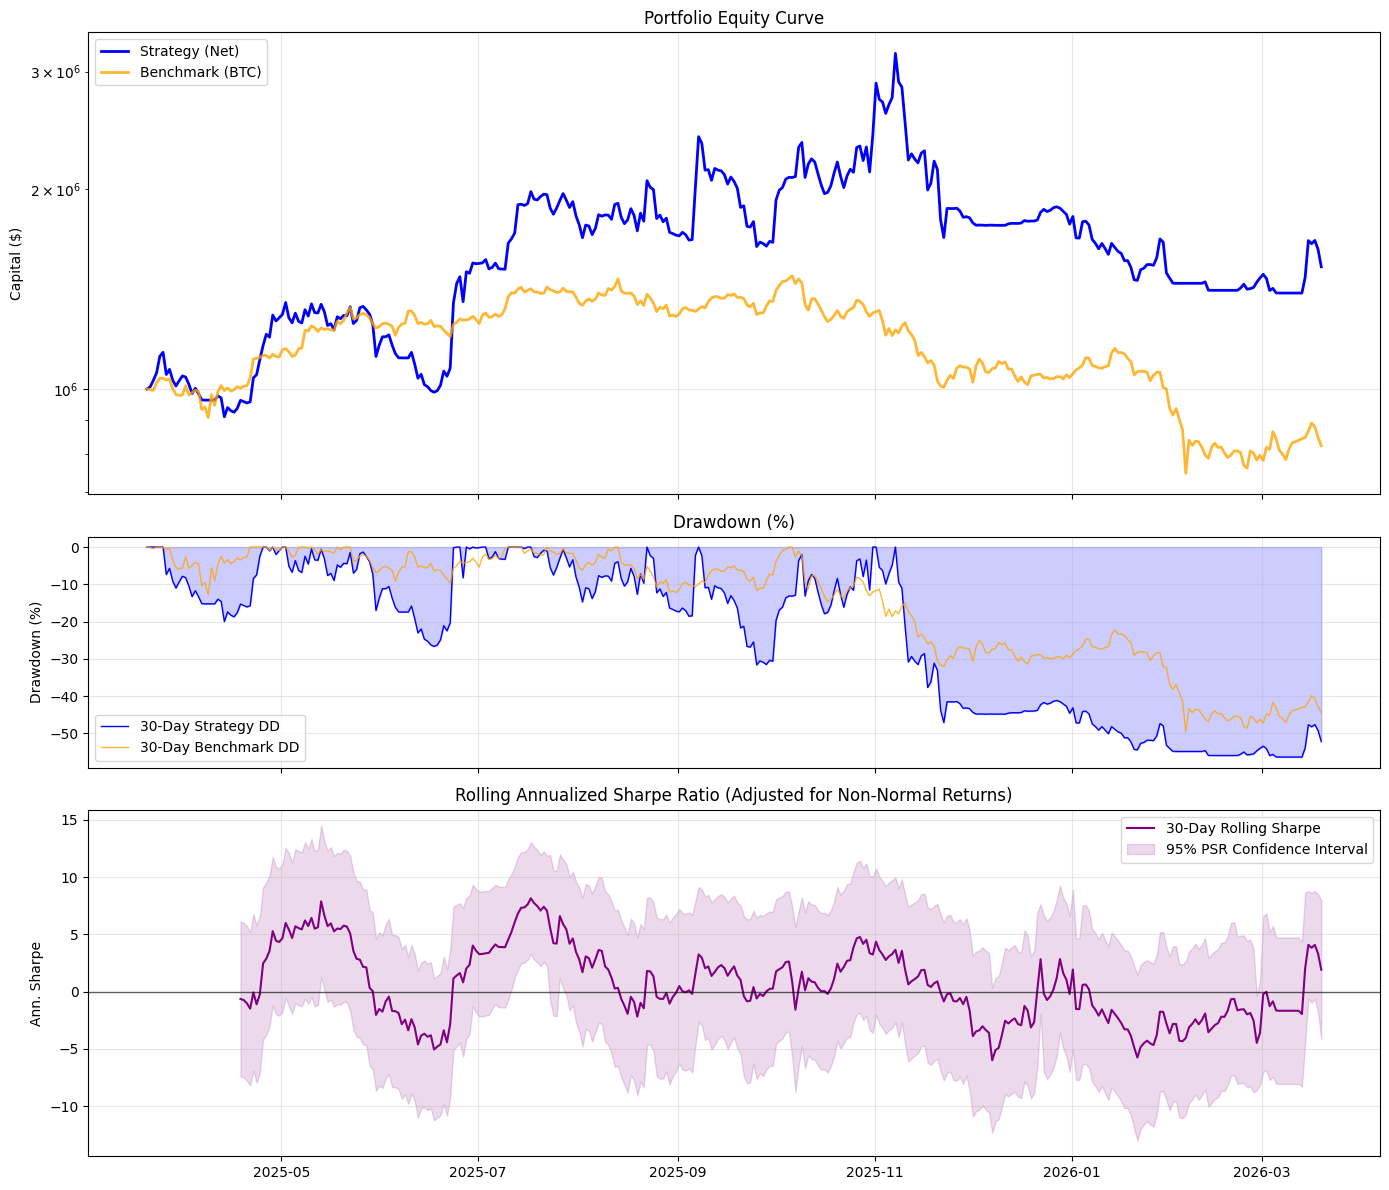

                     STRATEGY TEARSHEET                     
Metric                    |     Strategy |    Benchmark
-------------------------------------------------------
Total Return (%)          |        52.68 |       -17.82
Ann. Return (%)           |        52.68 |       -17.82
Ann. Volatility (%)       |        85.92 |        43.79
Max Drawdown (%)          |       -56.38 |       -49.53
Sharpe Ratio              |         0.61 |        -0.41
Probabilistic Sharpe (%)  |        82.48 |        40.95
Sortino Ratio             |         0.96 |        -0.56
Calmar Ratio              |         0.93 |        -0.36
Win Rate (%)              |        47.89 |        49.73
Daily Turnover (%)        |        29.83 |         0.00
Exact timestamp not found. Showing holdings for closest prior bar: 2026-03-18 08:00:00+08:00

Holdings on 2026-03-19:
- FET-USD: 33.3%
- TAO-USD: 33.3%
- TRX-USD: 33.3%
- CASH: 0.0%


In [ ]:
signal_generator = LongOnlyMomentumSignal(fast_span=5, slow_span=20, vol_span=260, z_score_threshold=0.8, top_n=5)

# Generate the weights DataFrame
close_1d = GetPriceData(db_path='../data/ohlcv_1d.duckdb').fetch_price_data()
btc_close_1d = close_1d['BTC-USD']
target_weights = signal_generator.generate_weights(close_1d)

# Feed the prices and weights into your backtester
backtester = VectorizedBacktester(
    prices=close_1d,
    weights=target_weights,
    benchmark_prices=btc_close_1d, # Optional BTC benchmark
    fee_rate=0.0010, 
    initial_capital=1e6, 
    periods_per_year=365,
    start_date='2025-03-20',
    end_date='2026-03-20'
)

# Run and evaluate
backtester.run()
backtester.plot_charts()
backtester.print_tearsheet()
crash_date = '2026-03-19'

holdings = backtester.get_holdings(crash_date)

print(f"\nHoldings on {crash_date}:")
for coin, weight in holdings.items():
    print(f"- {coin}: {weight*100:.1f}%")

# If the total weight is < 100%, the remainder is your Cash position!
total_invested = sum(holdings.values())
print(f"- CASH: {(1 - total_invested)*100:.1f}%")